# CAMB-Rayleigh Tutorial

This is a fork of [CAMB](https://camb.info) (v2.0.0) that adds **frequency-dependent
Rayleigh scattering** of CMB photons off neutral hydrogen and helium. Rayleigh
scattering is much stronger at higher frequency ($\propto \nu^4$ for the cross-spectrum
with the primary anisotropies, $\propto \nu^8$ for the Rayleigh signal's own auto-spectrum),
so it produces a small, frequency-dependent distortion of the CMB power spectra on top of
the (frequency-independent) primary signal -- something a standard CMB code, which treats
all frequency channels as identical copies of the same primary spectrum, cannot represent
at all.

**What this fork adds:**
- Per-frequency Rayleigh scattering opacity and visibility functions.
- A per-frequency photon Boltzmann hierarchy (the frequency channels are evolved alongside
  the primary, not as a separate post-processing step).
- $C_\ell$ **cross-spectra** between the primary and every requested frequency channel,
  and between channels themselves, **both lensed and unlensed** -- exposed through one new
  Python method, :meth:`results.get_rayleigh_cls`.

**What is unchanged:** everything else about CAMB works exactly as before. If you never set
`pars.SourceTerms.rayleigh_scattering = True`, this fork behaves identically to stock CAMB.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import camb

print("camb module path:", camb.__file__)
print("camb version:", camb.__version__)

camb module path: /Users/kwanitgangopadhyay/Desktop/PhD/Code/CAMB-Rayleigh/camb/__init__.py
camb version: 2.0.0


## 1. Turning on Rayleigh scattering

Two new parameters live on `pars.SourceTerms`, alongside CAMB's existing source-term
switches:

| Parameter | Type | Meaning |
|---|---|---|
| `rayleigh_scattering` | `bool` | On/off switch. `False` by default -- reproduces stock CAMB exactly. |
| `rayleigh_frequencies` | list of `float` | The frequency channels to compute, **in GHz**. |


In [2]:
pars = camb.set_params(
    H0=67.32,  # Hubble constant today, km/s/Mpc
    ombh2=0.022383,  # baryon physical density Omega_b h^2
    omch2=0.1201,  # cold dark matter physical density Omega_c h^2
    omk=0,  # curvature density (0 = flat) -- REQUIRED to be 0 for the Rayleigh columns, see Section 5
    YHe=0.2477055,  # helium mass fraction
    TCMB=2.7255,  # CMB temperature today, Kelvin
    nnu=3.046,  # effective number of neutrino species
    mnu=0,  # sum of neutrino masses, eV
    num_massive_neutrinos=0,  # how many of the nnu species are massive
    tau=0.05430842,  # reionization optical depth
    ns=0.9660,  # scalar spectral index
    As=2.10e-9,  # scalar power spectrum amplitude at the pivot scale
    WantTransfer=False,  # we don't need the matter transfer function/power spectrum here
    lmax=6000,  # internal calculation lmax;
    DoLensing=True,  # lens the primary AND every Rayleigh channel/cross-term
    lens_potential_accuracy=8,  # see the parameter table below -- this is what makes lensed
    # spectra trustworthy out to high ell; the AGENTS.md guidance for this repo recommends 8
    AccuracyBoost=1,  # overall integration accuracy; 1 (the default) is already sufficient here
)
pars.SourceTerms.rayleigh_scattering = True  # new to this fork: turn Rayleigh scattering on
pars.SourceTerms.rayleigh_frequencies = [143, 217, 353, 545, 857]  # new to this fork: bands, in GHz

import time

t0 = time.time()
results = camb.get_results(pars)
runtime_s = time.time() - t0
freqs = list(pars.SourceTerms.rayleigh_frequencies)

derived = results.get_derived_params()
print(f"z_star (recombination):    {derived['zstar']:.2f}")
print(f"r_star (sound horizon):    {derived['rstar']:.4f} Mpc")
print(f"100*theta_star:            {derived['thetastar']:.6f}")
print("Rayleigh bands:            ", freqs, "GHz")
print(f"camb.get_results runtime:   {runtime_s:.2f} s")
print()
print("--- derived accuracy settings (see the parameter table below) ---")
print(f"pars.max_l (internal calculation lmax):  {pars.max_l}")
print(f"pars.max_eta_k (internal k_eta_max):      {pars.max_eta_k:.0f}")
lmax_lensed_trustworthy = results.f_get_lmax_lensed()
print(f"trustworthy lensed lmax (f_get_lmax_lensed()): {lmax_lensed_trustworthy}")

z_star (recombination):    1089.98
r_star (sound horizon):    144.3971 Mpc
100*theta_star:            1.039482
Rayleigh bands:             [143.0, 217.0, 353.0, 545.0, 857.0] GHz
camb.get_results runtime:   3.03 s

--- derived accuracy settings (see the parameter table below) ---
pars.max_l (internal calculation lmax):  6200
pars.max_eta_k (internal k_eta_max):      144000
trustworthy lensed lmax (f_get_lmax_lensed()): 6050


## 2. The main API: `results.get_rayleigh_cls(...)`

This is the one new method that matters for most users. It returns the full covariance of
the primary and every Rayleigh frequency channel: every auto-spectrum and every
cross-spectrum, TT/EE/BB/TE, in one call.

```python
results.get_rayleigh_cls(lmax=None, CMB_unit=None, raw_cl=False, as_dict=False,
                          total=False, lensed=True)
```

**Standard CAMB options** (behave exactly like the equivalent options on
`get_lensed_scalar_cls`/`get_unlensed_scalar_cls` and friends):

| Option | Type | Default | Meaning |
|---|---|---|---|
| `lmax` | int or `None` | `None` -> trustworthy max (`f_get_lmax_lensed()` if `lensed=True`, else `pars.max_l`) | Maximum $\ell$ to return |
| `CMB_unit` | `None` or `'muK'` | `None` (dimensionless) | Use `'muK'` for $\mu K^2$ (temperature-squared) units |
| `raw_cl` | bool | `False` | `False`: return $D_\ell \equiv \ell(\ell+1)C_\ell/2\pi$. `True`: return the raw $C_\ell$ |
| `lensed` | bool | **`True`** | Return the lensed covariance. Pass `False` for the unlensed covariance. |

**The core return value** (`as_dict=False`, the default) is a numpy array of shape

```
(n_ch, n_ch, lmax+1, 4)
```

- **axis 0, axis 1** -- the two channels being cross-correlated. `n_ch = len(rayleigh_frequencies) + 1`.

  **Channel 0 is always the primary**; channels `1..n_ch-1` follow the order of
  `pars.SourceTerms.rayleigh_frequencies` (so with the 5 bands above, channel 1 = 143 GHz,
  ..., channel 5 = 857 GHz).

- **axis 2** -- multipole $\ell$, indexed directly (`arr[..., ell, ...]` for `ell = 0..lmax`;
  `ell < 2` is unphysical and zero-filled, same convention as the rest of CAMB).

- **axis 3** -- which spectrum: index `0=TT, 1=EE, 2=BB, 3=TE`. With the new `lensed=True`
  default, **BB is genuinely populated** (lensing converts E-mode power into B-mode power,
  even though nothing here sources primordial B-modes -- see Section 6).

**Differences, not totals, by default.** Except for the primary auto-spectrum
`arr[0,0]`, every entry is a **difference from the primary**: `arr[0,i]` is
$C_\ell^{T,\,dT_i} \equiv C_\ell^{T,\,T_i} - C_\ell^{T,\,T}$ (channel $i$'s temperature
MINUS the primary temperature, cross-correlated against the primary), and `arr[i,j]`
(`i,j>0`) is $C_\ell^{dT_i,\,dT_j}$. 

In [3]:
cls = results.get_rayleigh_cls(
    lmax=lmax_lensed_trustworthy, CMB_unit="muK", raw_cl=False, as_dict=False, total=False, lensed=True
)
ell = np.arange(cls.shape[2])

print("array shape:", cls.shape, " = (n_ch, n_ch, lmax+1, 4)")
print("n_ch =", cls.shape[0], "= 1 primary +", len(freqs), "Rayleigh bands")
print()
print("cls[0, 0, 100, 0]  -- lensed primary TT at ell=100:          ", cls[0, 0, 100, 0])
print("cls[0, 5, 100, 0]  -- lensed primary x 857 GHz (difference): ", cls[0, 5, 100, 0])
print("cls[5, 5, 100, 0]  -- lensed 857 GHz Rayleigh auto-spectrum: ", cls[5, 5, 100, 0])
print("cls[0, 0, 3000, 2] -- lensed primary BB at ell=3000 (0 unlensed, nonzero lensed):", cls[0, 0, 3000, 2])

array shape: (6, 6, 6051, 4)  = (n_ch, n_ch, lmax+1, 4)
n_ch = 6 = 1 primary + 5 Rayleigh bands

cls[0, 0, 100, 0]  -- lensed primary TT at ell=100:           2694.925888852714
cls[0, 5, 100, 0]  -- lensed primary x 857 GHz (difference):  -10.388889163831092
cls[5, 5, 100, 0]  -- lensed 857 GHz Rayleigh auto-spectrum:  6.646167470898914
cls[0, 0, 3000, 2] -- lensed primary BB at ell=3000 (0 unlensed, nonzero lensed): 0.022002150500733057


**The unlensed quantity is still one call away.** Just use `lensed=False` in calling the `get_rayleigh_cls()` function. The default value is `lensed=True` though.

In [4]:
cls_unlensed = results.get_rayleigh_cls(
    lmax=pars.max_l, CMB_unit="muK", raw_cl=False, as_dict=False, total=False, lensed=False
)
print("unlensed array shape:", cls_unlensed.shape)
print("unlensed primary BB (always exactly zero, no lensing applied):", cls_unlensed[0, 0, 100, 2])

unlensed array shape: (6, 6, 6201, 4)
unlensed primary BB (always exactly zero, no lensing applied): 0.0


### Dictionary access: `as_dict=True`

For interactive use, it is often more convenient to index by frequency (in GHz) directly
rather than by channel number. `as_dict=True` returns a `dict` keyed by
`(freq_i, freq_j)` tuples, with `0` standing for the primary:

In [5]:
cls_dict = results.get_rayleigh_cls(
    lmax=lmax_lensed_trustworthy, CMB_unit="muK", raw_cl=False, as_dict=True, total=False, lensed=True
)

print("number of keys:", len(cls_dict), " (= n_ch^2 =", cls.shape[0], "^2)")
print("a few example keys:", list(cls_dict.keys())[:8], "...")
print()
print("cls_dict[(0, 857)].shape:", cls_dict[(0, 857.0)].shape, " -- (lmax+1, 4), columns TT,EE,BB,TE")

number of keys: 36  (= n_ch^2 = 6 ^2)
a few example keys: [(0, 0), (0, 143.0), (0, 217.0), (0, 353.0), (0, 545.0), (0, 857.0), (143.0, 0), (143.0, 143.0)] ...

cls_dict[(0, 857)].shape: (6051, 4)  -- (lmax+1, 4), columns TT,EE,BB,TE


**Both `(a, b)` and `(b, a)` are stored, deliberately.** TT, EE and BB are symmetric under
swapping the two channels, but **TE is not**: $C_\ell^{T_i,\,E_j}$ (temperature from
channel $i$, E-polarization from channel $j$) genuinely differs from
$C_\ell^{T_j,\,E_i}$ whenever $i \neq j$, because the two channels have different
Rayleigh-scattering strength. Storing only a triangle would silently discard that
distinction. The cell below shows both properties directly on real numbers:

In [6]:
ell_check = 500
te_forward = cls_dict[(0, 857.0)][ell_check, 3]  # T_primary x E_857GHz
te_reverse = cls_dict[(857.0, 0)][ell_check, 3]  # T_857GHz x E_primary
print(f"TE at ell={ell_check}:  T_prim x E_857 = {te_forward:.5f}   T_857 x E_prim = {te_reverse:.5f}")
print(f"  -> different, as expected: {not np.isclose(te_forward, te_reverse)}")

tt_forward = cls_dict[(0, 857.0)][ell_check, 0]
tt_reverse = cls_dict[(857.0, 0)][ell_check, 0]
print(f"TT at ell={ell_check}:  0x857 = {tt_forward:.5f}   857x0 = {tt_reverse:.5f}")
print(f"  -> equal, as expected: {np.isclose(tt_forward, tt_reverse)}")

TE at ell=500:  T_prim x E_857 = 4.44698   T_857 x E_prim = 4.31524
  -> different, as expected: True
TT at ell=500:  0x857 = -109.36290   857x0 = -109.36290
  -> equal, as expected: True


### Reconstructing physical totals: `total=True`

By default (as explained above) everything except the primary auto-spectrum is a
*difference* from the primary. To get the physical total cross-spectrum between two actual
frequency channels -- e.g. "what would a real 143 GHz x 857 GHz cross-correlation look
like?" -- pass `total=True`. The total spectrum can be decomposed as

$$C_\ell^{T_i,\,T_j} = C_\ell^{T,T} + C_\ell^{T,\,dT_j} + C_\ell^{dT_i,\,T} + C_\ell^{dT_i,\,dT_j}$$

(and the analogous combination, respecting ordering, for EE and TE), where channel $0$
($T$, the primary) is treated as having zero "difference from itself", $T_i$ denotes the 
total at channel `i` (frequency $\nu_i$), and $d T_i$ denotes the Rayleigh correction 
at channel `i` (frequency $\nu_i$). 

In [7]:
cls_total = results.get_rayleigh_cls(
    lmax=lmax_lensed_trustworthy, CMB_unit="muK", raw_cl=False, as_dict=False, total=True, lensed=True
)
cls_total_dict = results.get_rayleigh_cls(
    lmax=lmax_lensed_trustworthy, CMB_unit="muK", raw_cl=False, as_dict=True, total=True, lensed=True
)

# self-consistency: manually apply the formula above and compare to total=True's output,
# for one representative pair (143 GHz x 857 GHz)
i, j = freqs.index(143) + 1, freqs.index(857) + 1
manual_TT = cls[0, 0, :, 0] + cls[0, j, :, 0] + cls[i, 0, :, 0] + cls[i, j, :, 0]
print("Manual reconstruction matches total=True:", np.allclose(manual_TT, cls_total[i, j, :, 0]))

Manual reconstruction matches total=True: True


Note that the **cross term dominates** the correction, not the auto term: for a small
perturbation $dT_i$ on top of the primary, the cross term $C_\ell^{T,\,dT_i}$ is *linear*
in the perturbation while the auto term $C_\ell^{dT_i,\,dT_i}$ is *quadratic*, so it is
generically much smaller. This is why the primary x Rayleigh **cross**-spectra are the 
more readily detectable signature of Rayleigh scattering, while
the Rayleigh **auto**-spectra are a smaller, sub-leading effect.

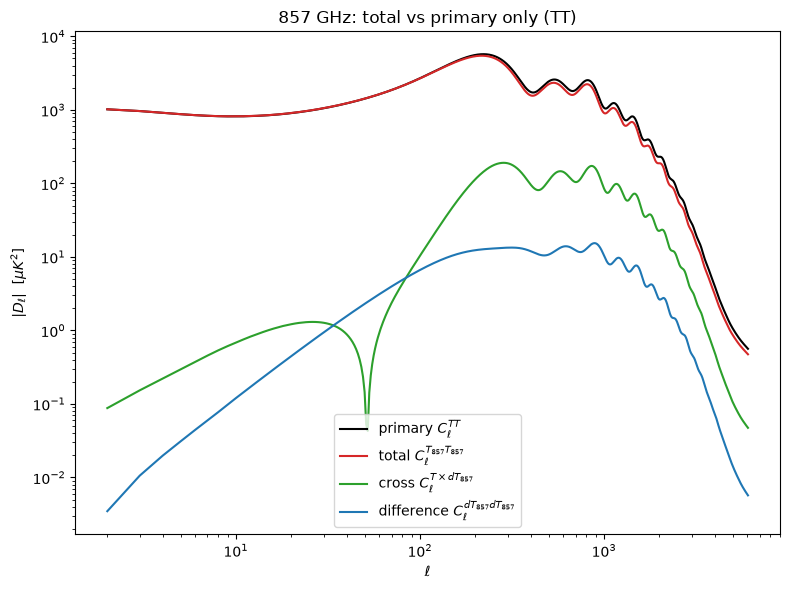

In [8]:
i857 = freqs.index(857) + 1

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(ell[2:], np.abs(cls[0, 0, 2:, 0]), color="k", label=r"primary $C_\ell^{TT}$")
ax.plot(ell[2:], np.abs(cls_total[i857, i857, 2:, 0]), color="C3", label=r"total $C_\ell^{T_{857}T_{857}}$")
ax.plot(ell[2:], np.abs(cls[0, i857, 2:, 0]), color="C2", label=r"cross $C_\ell^{T \times dT_{857}}$")
ax.plot(ell[2:], np.abs(cls[i857, i857, 2:, 0]), color="C0", label=r"difference $C_\ell^{dT_{857}dT_{857}}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$|D_\ell|$  [$\mu K^2$]")
ax.set_title("857 GHz: total vs primary only (TT)")
ax.legend()
fig.tight_layout()
plt.show()

The total (red) and the primary (black) lie almost exactly on top of each other -- the Rayleigh contribution is a small correction to the primary CMB, even at 857 GHz (the strongest band). The difference spectrum (blue) sits orders of magnitude below both. total=True is a convenience for comparing against data or other codes that expect physical totals; the default output is the difference.

Note that the **cross term** (green) dominates the correction, not the auto term: for a small perturbation $dT_i$
 on top of the primary, the cross term $C_\ell^{T_i, dT_i}$
 is linear in the perturbation while the auto term $C_\ell^{dT_i, dT_j}$
 is quadratic, so it is generically much smaller. This is why the primary x Rayleigh cross-spectra are the more readily detectable signature of Rayleigh scattering, while the Rayleigh auto-spectra are a smaller, sub-leading effect.

## 3. Visualizing the spectra


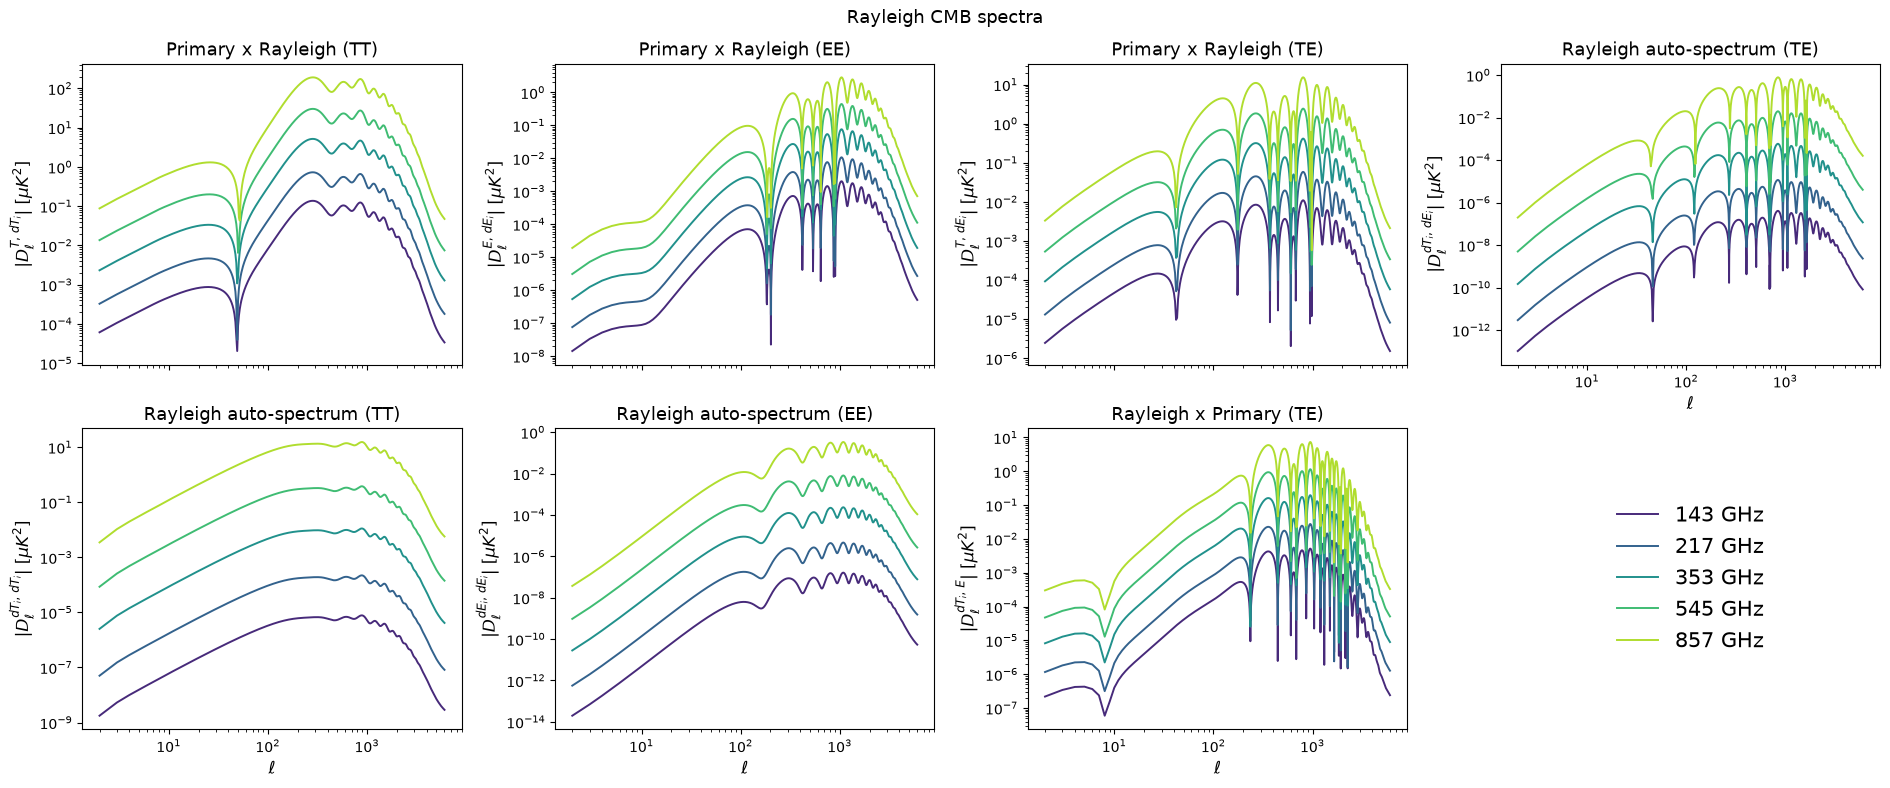

In [9]:
n_freq = len(freqs)
colors = plt.cm.viridis(np.linspace(0.12, 0.88, n_freq))
ell_plot = ell[2:]

fig, axes = plt.subplots(2, 4, figsize=(19, 8), sharex=True)

panels = [
    (axes[0, 0], "Primary x Rayleigh (TT)", r"$|D_\ell^{T,\,dT_i}|$ [$\mu K^2$]", lambda i: cls[0, i + 1, 2:, 0]),
    (axes[0, 1], "Primary x Rayleigh (EE)", r"$|D_\ell^{E,\,dE_i}|$ [$\mu K^2$]", lambda i: cls[0, i + 1, 2:, 1]),
    (axes[0, 2], "Primary x Rayleigh (TE)", r"$|D_\ell^{T,\,dE_i}|$ [$\mu K^2$]", lambda i: cls[0, i + 1, 2:, 3]),
    (
        axes[0, 3],
        "Rayleigh auto-spectrum (TE)",
        r"$|D_\ell^{dT_i,\,dE_i}|$ [$\mu K^2$]",
        lambda i: cls[i + 1, i + 1, 2:, 3],
    ),
    (
        axes[1, 0],
        "Rayleigh auto-spectrum (TT)",
        r"$|D_\ell^{dT_i,\,dT_i}|$ [$\mu K^2$]",
        lambda i: cls[i + 1, i + 1, 2:, 0],
    ),
    (
        axes[1, 1],
        "Rayleigh auto-spectrum (EE)",
        r"$|D_\ell^{dE_i,\,dE_i}|$ [$\mu K^2$]",
        lambda i: cls[i + 1, i + 1, 2:, 1],
    ),
    (axes[1, 2], "Rayleigh x Primary (TE)", r"$|D_\ell^{dT_i,\,E}|$ [$\mu K^2$]", lambda i: cls[i + 1, 0, 2:, 3]),
]

for ax, title, ylabel, get_y in panels:
    for i, (freq, color) in enumerate(zip(freqs, colors)):
        ax.plot(ell_plot, np.abs(get_y(i)), color=color, lw=1.4, label=f"{freq:.0f} GHz")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=12)

# unused slot in the 2x4 grid -- reused to hold the legend
axes[1, 3].axis("off")

for ax in axes[1, :3]:
    ax.set_xlabel(r"$\ell$", fontsize=12)
# column 3 has no panel beneath it, so restore its tick labels and axis label
axes[0, 3].tick_params(labelbottom=True)
axes[0, 3].set_xlabel(r"$\ell$", fontsize=12)

handles, labels = axes[0, 0].get_legend_handles_labels()
axes[1, 3].legend(handles, labels, loc="center", ncol=1, frameon=False, fontsize=15)

fig.suptitle("Rayleigh CMB spectra", fontsize=13)
fig.tight_layout()
plt.show()

**What to look for:**
- **TE vs ET genuinely differ** (top-right vs bottom-left panels): swapping which channel
  supplies temperature and which supplies polarization changes the cross-spectrum -- this
  is the same asymmetry demonstrated numerically above, now visible across the whole
  $\ell$ range and all five bands at once.

- **The $\nu^4$ ($\nu^8$ for auto-spectra) scaling with frequency** is visible as the
  near-constant vertical spacing between curves on this log-log plot: 857 GHz (yellow)
  sits orders of magnitude above 143 GHz (dark purple) in every panel -- consistent with
  Rayleigh scattering's steep frequency dependence.

- Every curve here is **lensed**. The BB power spectrum is completely due to lensing, 
  as tensor perturbations are null in this calculation.

- One can also plot other combinations, like **Rayleigh cross spectra** for $545 \times 857$ GHz.

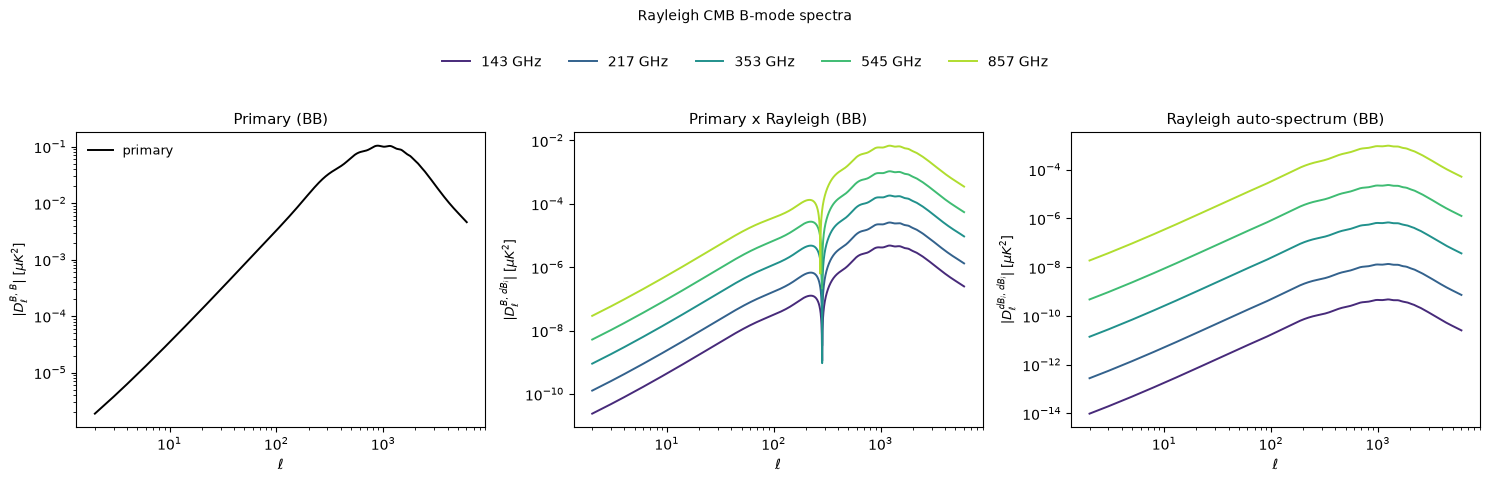

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True)

# Primary BB (lensing-induced only; Rayleigh sources no tensor modes)
axes[0].plot(ell_plot, np.abs(cls[0, 0, 2:, 2]), color="k", lw=1.4, label="primary")
axes[0].set_title("Primary (BB)", fontsize=11)
axes[0].set_ylabel(r"$|D_\ell^{B,\,B}|$ [$\mu K^2$]", fontsize=9)
axes[0].legend(frameon=False, fontsize=9)

bb_panels = [
    (axes[1], "Primary x Rayleigh (BB)", r"$|D_\ell^{B,\,dB_i}|$ [$\mu K^2$]", lambda i: cls[0, i + 1, 2:, 2]),
    (
        axes[2],
        "Rayleigh auto-spectrum (BB)",
        r"$|D_\ell^{dB_i,\,dB_i}|$ [$\mu K^2$]",
        lambda i: cls[i + 1, i + 1, 2:, 2],
    ),
]

for ax, title, ylabel, get_y in bb_panels:
    for i, (freq, color) in enumerate(zip(freqs, colors)):
        ax.plot(ell_plot, np.abs(get_y(i)), color=color, lw=1.4, label=f"{freq:.0f} GHz")
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=9)

for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\ell$", fontsize=10)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=n_freq, frameon=False, bbox_to_anchor=(0.5, 1.06), fontsize=10)
fig.suptitle("Rayleigh CMB B-mode spectra", y=1.14, fontsize=10)
fig.tight_layout(rect=(0, 0, 1, 1.0))
plt.show()

## 4. Other Rayleigh-specific accessors

`get_rayleigh_cls` is the accessor most users need. This fork also exposes a lower-level,
diagnostic accessor used during its own development/validation, which can be useful if you
want to look under the hood at *why* the spectra above look the way they do:

**`results.get_rayleigh_thermal_evolution(eta)`** -- per-frequency-channel opacity,
visibility, and $e^{-\tau}$ as a function of conformal time `eta` (an array, in Mpc).
Returns a `dict` with keys `'opacity'`, `'visibility'`, `'exptau'`, each an
`(n_eta, n_channels)` array, channel 0 = primary (Thomson-only), channels 1.. = the
Rayleigh bands. This is what actually generates the frequency dependence seen in the
$C_\ell$'s above: each channel sees a slightly different (larger) opacity and a slightly
different, narrower visibility function. (This accessor is unaffected by lensing -- it
describes recombination-era physics, before any line-of-sight lensing remapping.)

(There are two further, even lower-level accessors, `get_rayleigh_multipole_evolution` and
`get_rayleigh_source_evolution`, that expose per-wavenumber photon-multipole and
line-of-sight-source evolution. These exist purely as internal validation tools from this
fork's development and are not needed for ordinary use -- see their docstrings if you need
to inspect the Boltzmann hierarchy directly.)

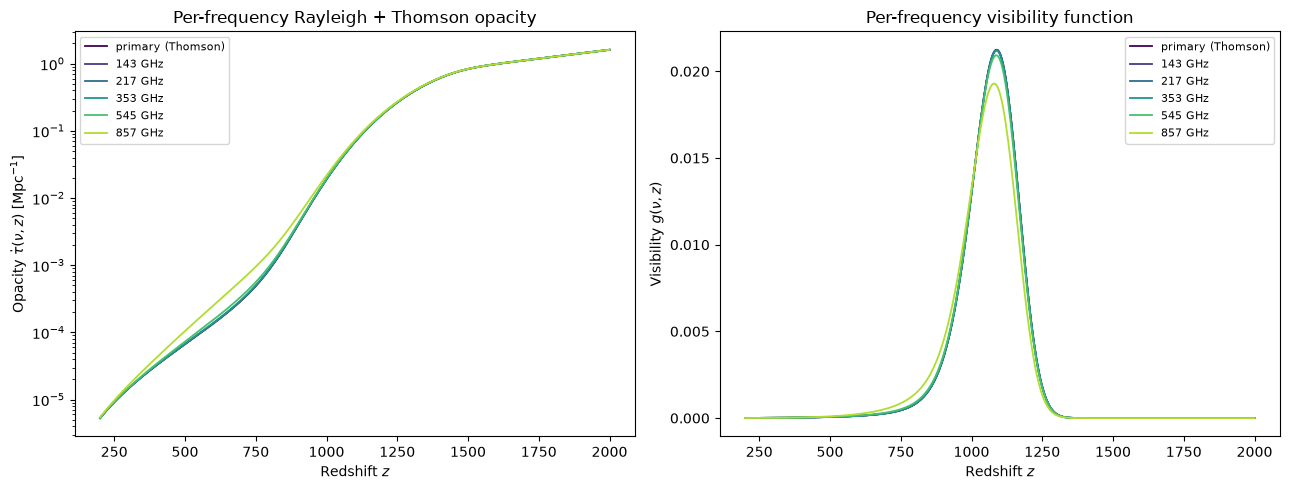

In [11]:
z_grid = np.linspace(200, 2000, 400)
eta_grid = results.conformal_time(z_grid)
evo = results.get_rayleigh_thermal_evolution(eta_grid)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ["primary (Thomson)"] + [f"{b:.0f} GHz" for b in freqs]
evo_colors = plt.cm.viridis(np.linspace(0, 0.88, len(labels)))

for i, (label, color) in enumerate(zip(labels, evo_colors)):
    axes[0].plot(z_grid, evo["opacity"][:, i], color=color, label=label, lw=1.3)
    axes[1].plot(z_grid, evo["visibility"][:, i], color=color, label=label, lw=1.3)

axes[0].set_yscale("log")
axes[0].set_xlabel("Redshift $z$")
axes[0].set_ylabel(r"Opacity $\dot\tau(\nu, z)$ [Mpc$^{-1}$]")
axes[0].set_title("Per-frequency Rayleigh + Thomson opacity")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Redshift $z$")
axes[1].set_ylabel(r"Visibility $g(\nu, z)$")
axes[1].set_title("Per-frequency visibility function")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

The raw curves above look almost identical across frequency -- the Rayleigh effect is a
small perturbation on top of the dominant Thomson-scattering opacity. Plotting the
*fractional* difference from the primary makes it visible:

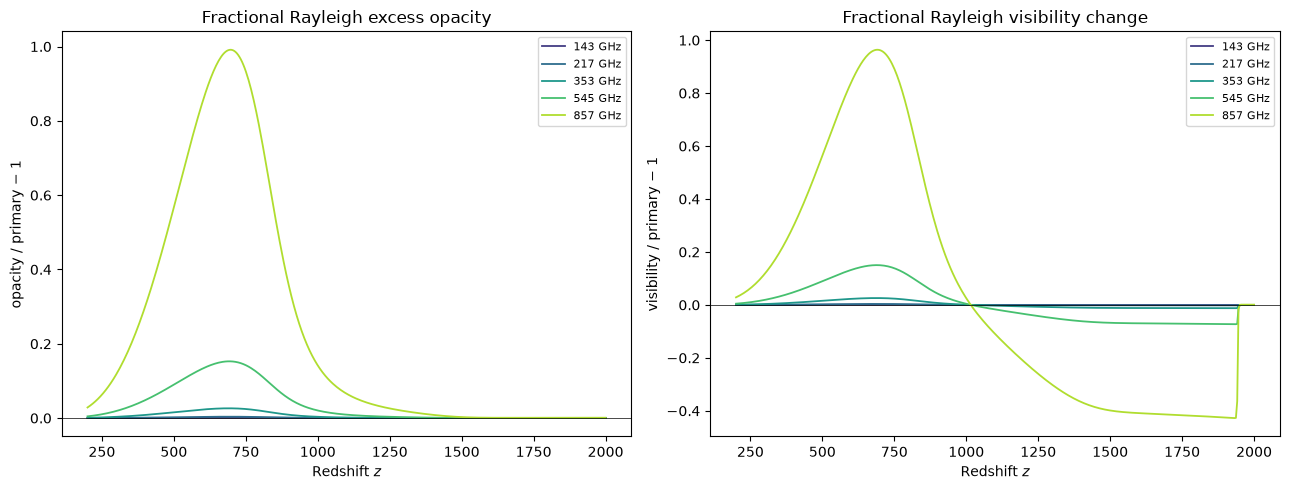

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, (band, color) in enumerate(zip(freqs, evo_colors[1:])):
    frac_opac = evo["opacity"][:, i + 1] / evo["opacity"][:, 0] - 1
    frac_vis = evo["visibility"][:, i + 1] / evo["visibility"][:, 0] - 1
    axes[0].plot(z_grid, frac_opac, color=color, label=f"{band:.0f} GHz", lw=1.3)
    axes[1].plot(z_grid, frac_vis, color=color, label=f"{band:.0f} GHz", lw=1.3)

for ax, name in zip(axes, ["opacity", "visibility"]):
    ax.set_xlabel("Redshift $z$")
    ax.set_ylabel(f"{name} / primary $-$ 1")
    ax.legend(fontsize=8)
    ax.axhline(0, color="k", lw=0.5)
axes[0].set_title("Fractional Rayleigh excess opacity")
axes[1].set_title("Fractional Rayleigh visibility change")
fig.tight_layout()
plt.show()